<a href="https://colab.research.google.com/github/suneetchugh-dev/Deep_Learning_Workshop/blob/main/DL_Image_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Introduction To Pytorch => We are using this CNN => Convolutional Neural Network

#Pytorch=> open source deep learning framework which is dynamic in nature

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3001,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)



print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]

Train Dataset Size: 60000
Test Dataset Size: 10000


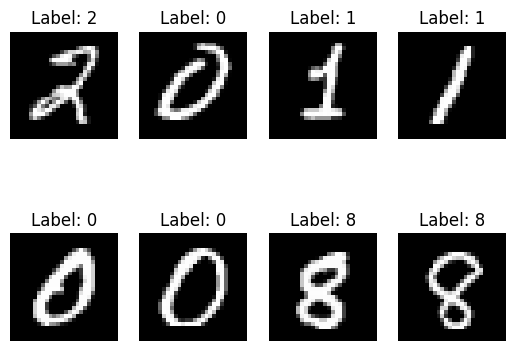

In [ ]:
images, labels = next(iter(train_loader))
for i in range(8):
  plt.subplot(2,4, i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"Label: {labels[i].item()}")
  plt.axis("off")

plt.show()

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels= 16,kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels= 16, out_channels= 16,kernel_size=3, padding=1) # FIX: in_channels should be 16

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #fully connected layer
        # Output after two pooling layers (28 -> 14 -> 7) and 16 channels from conv2
        self.fc1 = nn.Linear(16 * 7 * 7, 128) # FIX: fc1 output should be 128 for fc2
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x) # FIX: Apply pooling

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x) # Apply ReLU after fc1
        x = self.fc2(x) # Final layer, no ReLU here for CrossEntropyLoss

        return x

In [ ]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50

train_losses_history = []
train_accuracy_history = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)


    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/50], Loss: 0.0011, Accuracy: 99.97%
Epoch [2/50], Loss: 0.0002, Accuracy: 100.00%
Epoch [3/50], Loss: 0.0028, Accuracy: 99.92%
Epoch [4/50], Loss: 0.0043, Accuracy: 99.86%
Epoch [5/50], Loss: 0.0020, Accuracy: 99.94%
Epoch [6/50], Loss: 0.0011, Accuracy: 99.97%
Epoch [7/50], Loss: 0.0005, Accuracy: 99.98%
Epoch [8/50], Loss: 0.0047, Accuracy: 99.88%
Epoch [9/50], Loss: 0.0022, Accuracy: 99.95%
Epoch [10/50], Loss: 0.0021, Accuracy: 99.95%
Epoch [11/50], Loss: 0.0024, Accuracy: 99.95%
Epoch [12/50], Loss: 0.0030, Accuracy: 99.92%
Epoch [13/50], Loss: 0.0019, Accuracy: 99.93%
Epoch [14/50], Loss: 0.0014, Accuracy: 99.95%
Epoch [15/50], Loss: 0.0018, Accuracy: 99.96%
Epoch [16/50], Loss: 0.0027, Accuracy: 99.92%
Epoch [17/50], Loss: 0.0020, Accuracy: 99.95%
Epoch [18/50], Loss: 0.0022, Accuracy: 99.95%
Epoch [19/50], Loss: 0.0023, Accuracy: 99.94%
Epoch [20/50], Loss: 0.0008, Accuracy: 99.98%
Epoch [21/50], Loss: 0.0000, Accuracy: 100.00%
Epoch [22/50], Loss: 0.0022, Accuracy: 99

NameError: name 'train_losses_history' is not defined

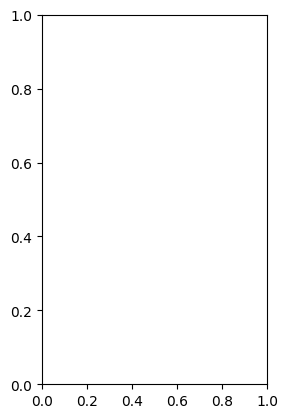

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1,2,1)
plt.plot(train_losses_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

Please Select An Image


Saving Only_Moutache.jpeg to Only_Moutache (2).jpeg

Uploaded Image: Only_Moutache (2).jpeg


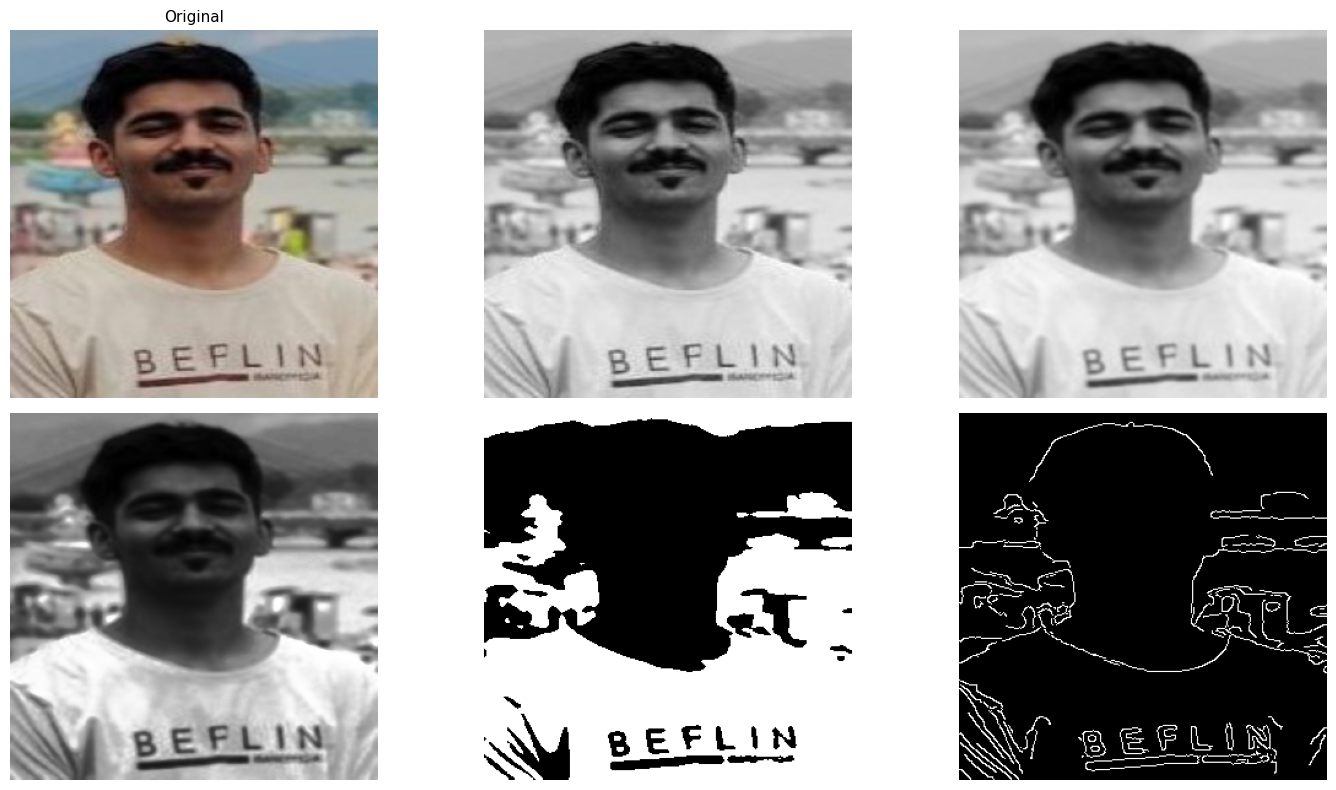

In [ ]:
#Image Processing Using Open CV

#Upload image using button open collab

import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
import os

print("Please Select An Image")

uploaded = files.upload()


#Get uploaded file name

image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#load Image

image = cv2.imread(image_path) #this is us reading the image using opencv

if image is None:
  raise FileNotFoundError("Image Could Not Be Loaded")

#Convert BGR to RGB

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #Converting the image to RGB since Open CV only takes images in BGR


#RESIZE IMAGE

resized = cv2.resize(image_rgb, (300,300))

#GRAYSCALE

gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)


#GAUSSIAN_BLUR

blur = cv2.GaussianBlur(gray, (5,5), 0)

#Histogram EQUALIZATION

equalized = cv2.equalizeHist(blur)


#Thresholding //This is us setting up threshold image

_, threshold_img = cv2.threshold(
    equalized,
    127,
    255,
    cv2.THRESH_BINARY
)



#EDGE DETECTION
edges = cv2.Canny(
    equalized,
    100,
    200
)


#DISPLAY ALL RESULTS

titles = [
    "Original",
    "Grayscale",
    "Gaussian Blur",
    "Histogram Equalization",
    "Threshold",
    "Edge Detection"
]


images = [
    resized,
    gray,
    blur,
    equalized,
    threshold_img,
    edges
]


plt.figure(figsize=(15,8))

for i in range(len(images)):
  plt.subplot(2,3,i+1)

  if len(images[i].shape) == 2:
    plt.imshow(images[i], cmap="gray")
  else:
    plt.imshow(images[i])

    plt.title(titles[i], fontsize=11)
  plt.axis("off")

plt.tight_layout()
plt.show()

UPLOAD AN IMAGE


Saving IMG-20251021-WA0020.jpg to IMG-20251021-WA0020 (1).jpg

Uploaded Image: IMG-20251021-WA0020 (1).jpg

Loading YOLOv8 Model...
PRO TIP 💡 Replace 'model=yolov5x.pt' with new 'model=yolov5xu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.
Model Loaded Successfully

Performing object Detetction

image 1/1 /content/IMG-20251021-WA0020 (1).jpg: 640x480 1 person, 1 cat, 1 dog, 1 pizza, 80.3ms
Speed: 2.0ms preprocess, 80.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Detection Completed Successfully


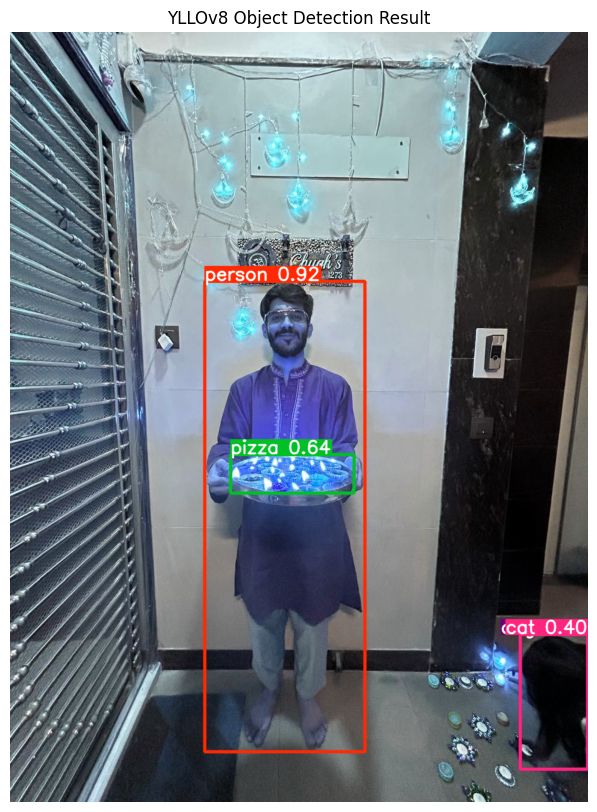


Detected Objects

Object 1
------------------------------
Class Name: person
Confidence: 0.9150382876396179

Total Objects Detected : 4

Object 2
------------------------------
Class Name: pizza
Confidence: 0.6449941396713257

Total Objects Detected : 4

Object 3
------------------------------
Class Name: cat
Confidence: 0.39882275462150574

Total Objects Detected : 4

Object 4
------------------------------
Class Name: dog
Confidence: 0.2849462032318115

Total Objects Detected : 4


In [6]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov5x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)

UPLOAD AN IMAGE


Saving IMG-20251021-WA0018.jpg to IMG-20251021-WA0018.jpg

Uploaded Image: IMG-20251021-WA0018.jpg

Loading YOLOv8 Model...
Model Loaded Successfully

Performing object Detetction

image 1/1 /content/IMG-20251021-WA0018.jpg: 640x480 1 person, 1 donut, 71.1ms
Speed: 2.1ms preprocess, 71.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Detection Completed Successfully


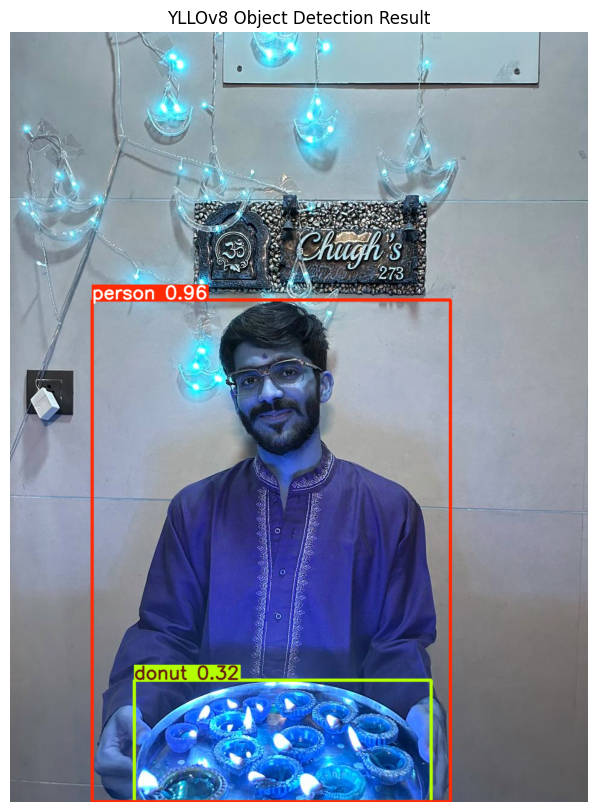


Detected Objects

Object 1
------------------------------
Class Name: person
Confidence: 0.9581605195999146

Total Objects Detected : 2

Object 2
------------------------------
Class Name: donut
Confidence: 0.31927451491355896

Total Objects Detected : 2


In [8]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov8x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)